<a href="https://colab.research.google.com/github/pilaaaar/ANALISIS-NUMERICO/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd

# Load the DM.csv dataset
df = pd.read_csv('/content/DM.csv')

# Display the first 5 rows and general information of the DataFrame
print("Initial DataFrame head:")
display(df.head())
print("\nInitial DataFrame info:")
df.info()

Initial DataFrame head:


,Grupo,Participante,Minuto,C3,C4,CZ,EMG,F3,F4,F7,...,O1,O2,P3,P4,PZ,ROG,T3,T4,T5,T6
0,0,EMV,1,1.457191,1.465362,1.389850,1.469966,1.471585,1.383370,1.416681,...,1.419505,1.460171,1.435626,1.401177,1.405440,1.190718,1.486129,1.455536,1.457664,1.464154
1,0,EMV,10,1.442564,1.372664,1.361794,1.310307,1.477391,1.366440,1.439025,...,1.417780,1.421081,1.410483,1.395753,1.393475,1.116700,1.474367,1.413287,1.477452,1.412524
2,0,EMV,11,1.445738,1.397893,1.363018,1.246467,1.451693,1.372738,1.398308,...,1.444138,1.434578,1.425999,1.411785,1.403913,1.118753,1.472099,1.433305,1.484939,1.440299
3,0,EMV,12,1.381500,1.422462,1.443394,1.445102,1.422085,1.413301,1.450779,...,1.427840,1.451817,1.403597,1.434047,1.428170,1.167026,1.428117,1.453502,1.373695,1.437340
4,0,EMV,13,1.443665,1.355041,1.360214,1.301061,1.474152,1.365256,1.433039,...,1.415445,1.402281,1.391482,1.395755,1.400138,1.139237,1.464603,1.404249,1.453814,1.405438



Initial DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Grupo         900 non-null    int64  
 1   Participante  900 non-null    object 
 2   Minuto        900 non-null    int64  
 3   C3            900 non-null    float64
 4   C4            900 non-null    float64
 5   CZ            900 non-null    float64
 6   EMG           450 non-null    float64
 7   F3            900 non-null    float64
 8   F4            900 non-null    float64
 9   F7            900 non-null    float64
 10  F8            900 non-null    float64
 11  FP1           900 non-null    float64
 12  FP2           900 non-null    float64
 13  FZ            900 non-null    float64
 14  LOG           900 non-null    float64
 15  O1            900 non-null    float64
 16  O2            900 non-null    float64
 17  P3            900 non-null    float64
 18  P4   

### 1. Preparación de los datos

Primero, separamos las características (X) de la variable objetivo (y). La variable objetivo es 'Grupo'.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define target variable (y) and features (X)
# Drop 'Participante' and 'EMG' as they are not suitable for direct use in KNN
X = df.drop(['Grupo', 'Participante', 'EMG'], axis=1)
y = df['Grupo']

print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,Minuto,C3,C4,CZ,F3,F4,F7,F8,FP1,FP2,...,O1,O2,P3,P4,PZ,ROG,T3,T4,T5,T6
0,1,1.457191,1.465362,1.389850,1.471585,1.383370,1.416681,1.335028,1.172173,1.166584,...,1.419505,1.460171,1.435626,1.401177,1.405440,1.190718,1.486129,1.455536,1.457664,1.464154
1,10,1.442564,1.372664,1.361794,1.477391,1.366440,1.439025,1.269399,1.220473,1.181741,...,1.417780,1.421081,1.410483,1.395753,1.393475,1.116700,1.474367,1.413287,1.477452,1.412524
2,11,1.445738,1.397893,1.363018,1.451693,1.372738,1.398308,1.285700,1.211166,1.194989,...,1.444138,1.434578,1.425999,1.411785,1.403913,1.118753,1.472099,1.433305,1.484939,1.440299
3,12,1.381500,1.422462,1.443394,1.422085,1.413301,1.450779,1.404926,1.343141,1.306630,...,1.427840,1.451817,1.403597,1.434047,1.428170,1.167026,1.428117,1.453502,1.373695,1.437340
4,13,1.443665,1.355041,1.360214,1.474152,1.365256,1.433039,1.281785,1.230395,1.214625,...,1.415445,1.402281,1.391482,1.395755,1.400138,1.139237,1.464603,1.404249,1.453814,1.405438



Target (y) head:


,Grupo
0,0
1,0
2,0
3,0
4,0


### 2. División de los datos en conjuntos de entrenamiento y prueba

Dividimos los datos en un 70% para entrenamiento y un 30% para prueba.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (630, 22)
X_test shape: (270, 22)
y_train shape: (630,)
y_test shape: (270,)


### 3. Escalado de las características

KNN es sensible a la escala de las características, por lo que estandarizamos los datos.

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled first 5 rows (after scaling):\n", X_train_scaled[:5])

X_train_scaled first 5 rows (after scaling):
 [[ 1.20295705 -0.87404518 -0.02185267 -0.66239587 -1.3852618  -0.27117219
  -1.26732106 -0.92571181 -0.79591012 -0.44236777 -0.9667713  -1.03942056
  -0.12593322  0.33223233  0.46620172  0.06101829  0.26031882 -2.15401416
  -0.19897428  0.46035364  0.99240488  1.18879675]
 [-0.79504525  0.83260453  1.28895734  1.71837959  1.19841837  0.22115757
  -0.00774398 -0.5562507   1.26481571  1.40730323  1.37062217  1.02893985
   1.04829349  1.54413553  1.03105302  0.86572226  1.54450654  0.75911035
   0.25820314  0.27617613 -0.41397572  1.38613275]
 [-1.3462183   0.1482078  -1.16503856 -0.40951417 -0.8714051  -0.21933722
  -0.96900676 -0.83581003 -0.76973598  0.08805065 -0.32831739 -0.43920747
  -0.3751461  -0.15629848 -0.32702517 -0.68902581 -1.19863031  0.46423764
  -0.68337    -0.68400992 -0.97079259 -0.74133788]
 [-1.55290819 -0.85544136 -1.27676257 -1.31764156 -1.04614531 -1.46604441
  -0.77583674 -1.39172832 -1.068994   -1.08873463 -1.39721244

### 4. Entrenamiento del modelo KNN

Entrenamos un clasificador KNN. Empezaremos con un número de vecinos (k) de 5.

In [24]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

print("KNN model trained successfully.")

KNN model trained successfully.


### 5. Evaluación del modelo

Realizamos predicciones sobre el conjunto de prueba y evaluamos el rendimiento del modelo.

In [25]:
y_pred = knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.837037037037037

Confusion Matrix:
 [[138  19]
 [ 25  88]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.88      0.86       157
           1       0.82      0.78      0.80       113

    accuracy                           0.84       270
   macro avg       0.83      0.83      0.83       270
weighted avg       0.84      0.84      0.84       270



### 6. Búsqueda del mejor valor de K (número de vecinos)

Podemos iterar sobre diferentes valores de `k` para encontrar el que ofrece la mejor precisión.

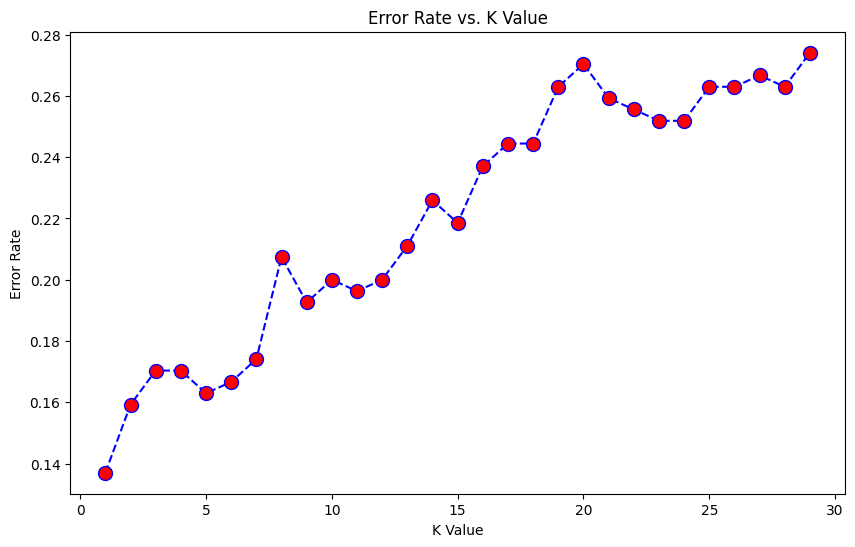

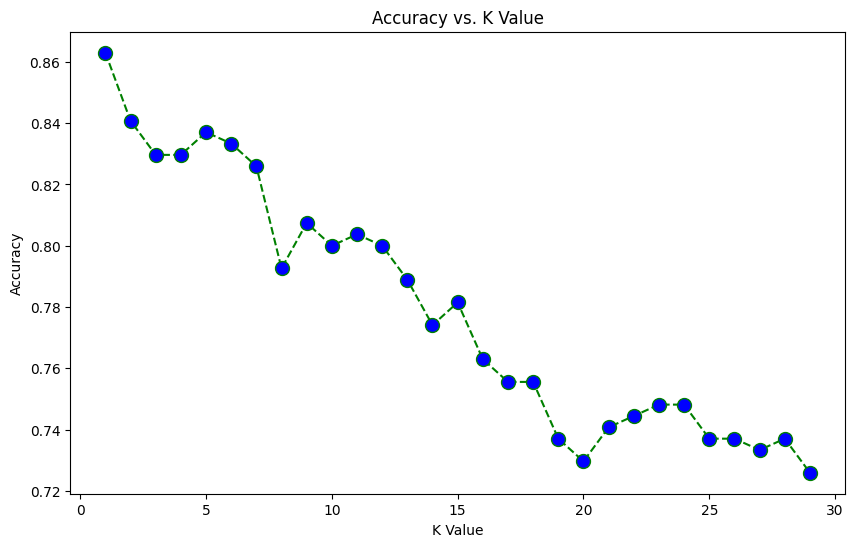

The best K value is: 1 with an accuracy of 0.8630


In [26]:
accuracy_scores = []
error_rates = []

for i in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    pred_i = knn.predict(X_test_scaled)
    accuracy_scores.append(accuracy_score(y_test, pred_i))
    error_rates.append(1 - accuracy_score(y_test, pred_i))

plt.figure(figsize=(10, 6))
plt.plot(range(1, 30), error_rates, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, 30), accuracy_scores, color='green', linestyle='dashed', marker='o', markerfacecolor='blue', markersize=10)
plt.title('Accuracy vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.show()

best_k = accuracy_scores.index(max(accuracy_scores)) + 1
print(f"The best K value is: {best_k} with an accuracy of {max(accuracy_scores):.4f}")

### 7. Entrenamiento y evaluación con el mejor valor de K

Finalmente, entrenamos y evaluamos el modelo con el `k` óptimo.

In [27]:
knn_optimal = KNeighborsClassifier(n_neighbors=best_k)
knn_optimal.fit(X_train_scaled, y_train)
y_pred_optimal = knn_optimal.predict(X_test_scaled)

print(f"Accuracy with optimal K ({best_k}):", accuracy_score(y_test, y_pred_optimal))
print("\nConfusion Matrix with optimal K:\n", confusion_matrix(y_test, y_pred_optimal))
print("\nClassification Report with optimal K:\n", classification_report(y_test, y_pred_optimal))

Accuracy with optimal K (1): 0.8629629629629629

Confusion Matrix with optimal K:
 [[141  16]
 [ 21  92]]

Classification Report with optimal K:
               precision    recall  f1-score   support

           0       0.87      0.90      0.88       157
           1       0.85      0.81      0.83       113

    accuracy                           0.86       270
   macro avg       0.86      0.86      0.86       270
weighted avg       0.86      0.86      0.86       270



In [29]:
from sklearn.metrics import classification_report
import pandas as pd

# Generate the classification report as a dictionary
report_dict = classification_report(y_test, y_pred_optimal, output_dict=True)

# Convert the dictionary to a pandas DataFrame
df_report = pd.DataFrame(report_dict).transpose()

# Save the DataFrame to a CSV file
output_csv_path = 'classification_report.csv'
df_report.to_csv(output_csv_path)

print(f"Classification report successfully exported to '{output_csv_path}'")
display(df_report)

Classification report successfully exported to 'classification_report.csv'


,precision,recall,f1-score,support
0,0.870370,0.898089,0.884013,157.000000
1,0.851852,0.814159,0.832579,113.000000
accuracy,0.862963,0.862963,0.862963,0.862963
macro avg,0.861111,0.856124,0.858296,270.000000
weighted avg,0.862620,0.862963,0.862487,270.000000


In [28]:
# Drop the 'EMG' and 'Patient' columns as requested
# Check if columns exist before dropping to avoid errors
columns_to_drop = []
if 'EMG' in df.columns:
    columns_to_drop.append('EMG')
    print("Dropping 'EMG' column.")
if 'Patient' in df.columns:
    columns_to_drop.append('Patient')
    print("Dropping 'Patient' column.")

if columns_to_drop:
    df = df.drop(columns=columns_to_drop)
else:
    print("Columns 'EMG' and 'Patient' not found in the dataset.")

# Display the DataFrame info after dropping columns
print("\nDataFrame info after dropping columns:")
df.info()
print("\nDataFrame head after dropping columns:")
display(df.head())

Dropping 'EMG' column.

DataFrame info after dropping columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Grupo         900 non-null    int64  
 1   Participante  900 non-null    object 
 2   Minuto        900 non-null    int64  
 3   C3            900 non-null    float64
 4   C4            900 non-null    float64
 5   CZ            900 non-null    float64
 6   F3            900 non-null    float64
 7   F4            900 non-null    float64
 8   F7            900 non-null    float64
 9   F8            900 non-null    float64
 10  FP1           900 non-null    float64
 11  FP2           900 non-null    float64
 12  FZ            900 non-null    float64
 13  LOG           900 non-null    float64
 14  O1            900 non-null    float64
 15  O2            900 non-null    float64
 16  P3            900 non-null    float64
 17  P4        

,Grupo,Participante,Minuto,C3,C4,CZ,F3,F4,F7,F8,...,O1,O2,P3,P4,PZ,ROG,T3,T4,T5,T6
0,0,EMV,1,1.457191,1.465362,1.389850,1.471585,1.383370,1.416681,1.335028,...,1.419505,1.460171,1.435626,1.401177,1.405440,1.190718,1.486129,1.455536,1.457664,1.464154
1,0,EMV,10,1.442564,1.372664,1.361794,1.477391,1.366440,1.439025,1.269399,...,1.417780,1.421081,1.410483,1.395753,1.393475,1.116700,1.474367,1.413287,1.477452,1.412524
2,0,EMV,11,1.445738,1.397893,1.363018,1.451693,1.372738,1.398308,1.285700,...,1.444138,1.434578,1.425999,1.411785,1.403913,1.118753,1.472099,1.433305,1.484939,1.440299
3,0,EMV,12,1.381500,1.422462,1.443394,1.422085,1.413301,1.450779,1.404926,...,1.427840,1.451817,1.403597,1.434047,1.428170,1.167026,1.428117,1.453502,1.373695,1.437340
4,0,EMV,13,1.443665,1.355041,1.360214,1.474152,1.365256,1.433039,1.281785,...,1.415445,1.402281,1.391482,1.395755,1.400138,1.139237,1.464603,1.404249,1.453814,1.405438
